In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [4]:
df = pd.read_csv('tips.csv')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.shape

(244, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         243 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        243 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [7]:
df.describe()

,total_bill,tip,size
count,244.000000,243.000000,244.000000
mean,19.785943,3.006502,2.569672
std,8.902412,1.380506,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.920000,2.000000
75%,24.127500,3.575000,3.000000
max,50.810000,10.000000,6.000000


In [8]:
df.describe(include='object')

,sex,smoker,day,time
count,244,244,244,243
unique,4,2,4,2
top,Male,No,Sat,Dinner
freq,156,151,87,175


In [9]:
df.isnull().sum()

total_bill    0
tip           1
sex           0
smoker        0
day           0
time          1
size          0
dtype: int64

In [10]:
df[df.isnull().any(axis=1)]

,total_bill,tip,sex,smoker,day,time,size
67,3.07,NaN,Female,Yes,Sat,Dinner,1
94,22.75,3.25,Female,No,Fri,NaN,2


In [11]:
df_clean = df.dropna()
print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)

Original shape: (244, 7)
Clean shape: (242, 7)


In [12]:
df_clean.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [30]:
df_clean['sex'].value_counts()
df_clean.head()

,total_bill,tip,sex,smoker,day,time,size,tip_rate
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808


In [14]:
df_clean = df_clean.copy()  # To avoid SettingWithCopyWarning
df_clean['sex'] = df_clean['sex'].replace('female', 'Female').replace('male', 'Male')

In [15]:
df_clean['sex'].value_counts()

sex
Male      157
Female     85
Name: count, dtype: int64

In [31]:
valid_sex = ['Male', 'Female']
df_clean[~df_clean['sex'].isin(valid_sex)]

,total_bill,tip,sex,smoker,day,time,size,tip_rate


In [17]:
for col in df_clean.columns:
    print(f'Field: {col}')
    print(df_clean[col].value_counts())

Field: total_bill
total_bill
13.42    3
21.01    2
10.34    2
20.29    2
20.69    2
        ..
29.03    1
27.18    1
22.67    1
17.82    1
18.78    1
Name: count, Length: 227, dtype: int64
Field: tip
tip
2.00    33
3.00    23
4.00    12
2.50    10
5.00    10
        ..
1.47     1
1.17     1
4.67     1
5.92     1
1.75     1
Name: count, Length: 123, dtype: int64
Field: sex
sex
Male      157
Female     85
Name: count, dtype: int64
Field: smoker
smoker
No     150
Yes     92
Name: count, dtype: int64
Field: day
day
Sat     86
Sun     76
Thur    62
Fri     18
Name: count, dtype: int64
Field: time
time
Dinner    174
Lunch      68
Name: count, dtype: int64
Field: size
size
2    155
3     38
4     37
5      5
6      4
1      3
Name: count, dtype: int64


In [18]:
df_clean['tip_rate'] = df_clean['tip'] / df_clean['total_bill']
df_clean.head()

,total_bill,tip,sex,smoker,day,time,size,tip_rate
0,16.99,1.01,Female,No,Sun,Dinner,2,0.059447
1,10.34,1.66,Male,No,Sun,Dinner,3,0.160542
2,21.01,3.50,Male,No,Sun,Dinner,3,0.166587
3,23.68,3.31,Male,No,Sun,Dinner,2,0.139780
4,24.59,3.61,Female,No,Sun,Dinner,4,0.146808


In [19]:
df_clean[['total_bill', 'tip', 'tip_rate', 'size']].describe()

,total_bill,tip,tip_rate,size
count,242.000000,242.000000,242.000000,242.000000
mean,19.842769,3.005496,0.160195,2.578512
std,8.871951,1.383278,0.060384,0.948920
min,5.750000,1.000000,0.035638,1.000000
25%,13.375000,2.000000,0.128538,2.000000
50%,17.795000,2.900000,0.154770,2.000000
75%,24.222500,3.587500,0.191022,3.000000
max,50.810000,10.000000,0.710345,6.000000


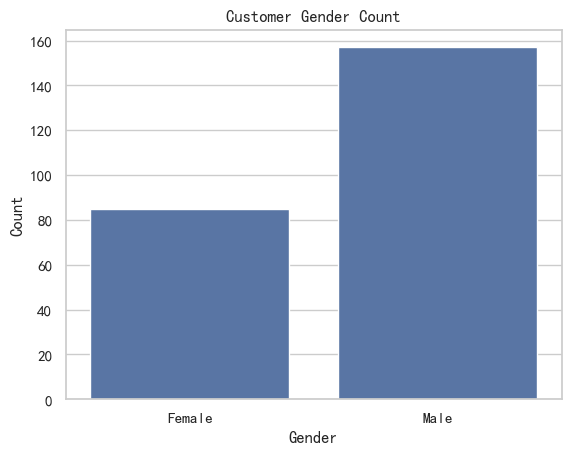

In [20]:
sns.countplot(data=df_clean, x='sex')
plt.title('Customer Gender Count')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

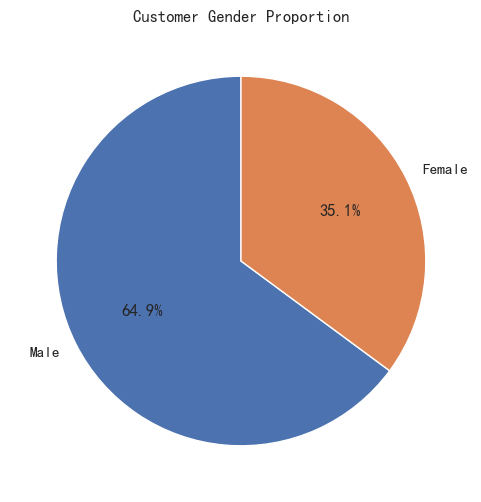

In [21]:
sex_counts = df_clean['sex'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Customer Gender Proportion')
plt.show()

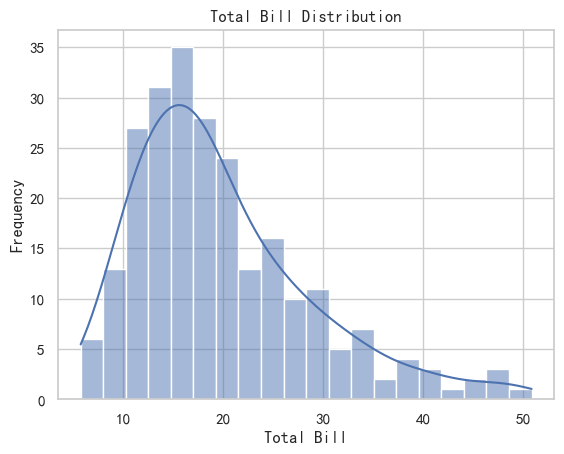

In [22]:
sns.histplot(data=df_clean, x='total_bill', bins=20, kde=True)
plt.title('Total Bill Distribution')
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.show()

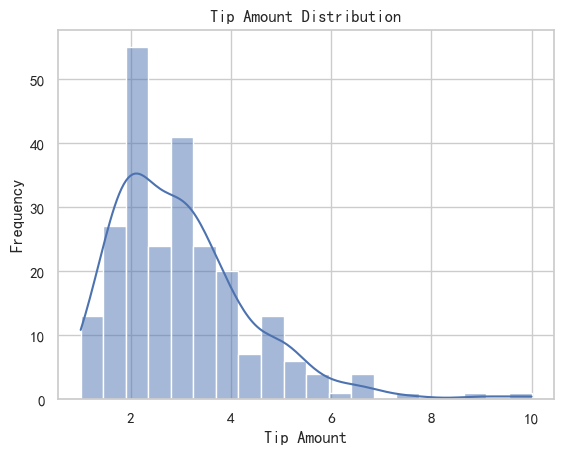

In [23]:
sns.histplot(df_clean['tip'], bins=20, kde=True)
plt.title('Tip Amount Distribution')
plt.xlabel('Tip Amount')
plt.ylabel('Frequency')
plt.show()

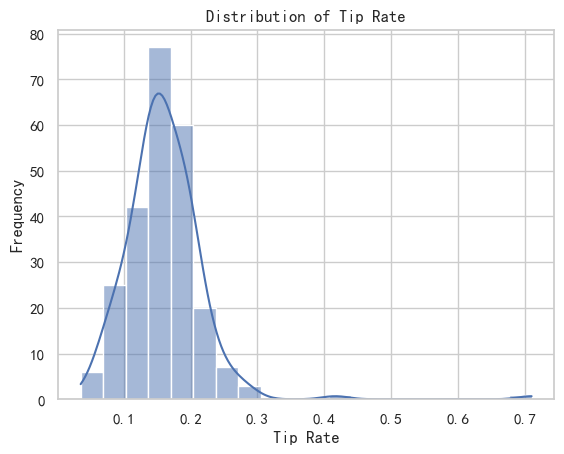

In [24]:
sns.histplot(df_clean['tip_rate'], bins=20, kde=True)
plt.title('Distribution of Tip Rate')
plt.xlabel('Tip Rate')
plt.ylabel('Frequency')
plt.show()

In [25]:
df_clean.groupby('sex')[['total_bill', 'tip', 'tip_rate']].mean()

,total_bill,tip,tip_rate
sex,,,
Female,18.178000,2.850118,0.164895
Male,20.744076,3.089618,0.157651


In [26]:
df_clean.groupby('time')[['total_bill', 'tip', 'tip_rate']].mean()

,total_bill,tip,tip_rate
time,,,
Dinner,20.887816,3.113908,0.158658
Lunch,17.168676,2.728088,0.164128


In [27]:
df_clean.groupby('day')[['total_bill', 'tip', 'tip_rate']].mean()

,total_bill,tip,tip_rate
day,,,
Fri,16.840556,2.706111,0.171416
Sat,20.643372,3.016279,0.151145
Sun,21.410000,3.255132,0.166897
Thur,17.682742,2.771452,0.161276


In [28]:
df_clean.groupby('smoker')[['total_bill', 'tip', 'tip_rate']].mean()

,total_bill,tip,tip_rate
smoker,,,
No,19.164533,2.990133,0.159438
Yes,20.948587,3.030543,0.161429


In [42]:
day_order = sorted(df_clean['day'].unique())

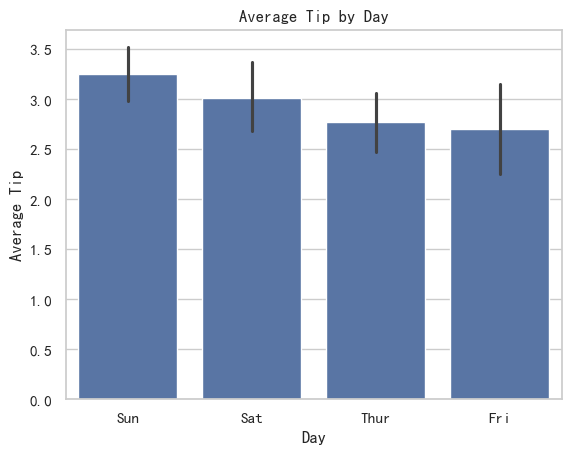

In [48]:
sns.barplot(data=df_clean, x='day', y='tip')
plt.title("Average Tip by Day")
plt.xlabel("Day")
plt.ylabel("Average Tip")
plt.show()

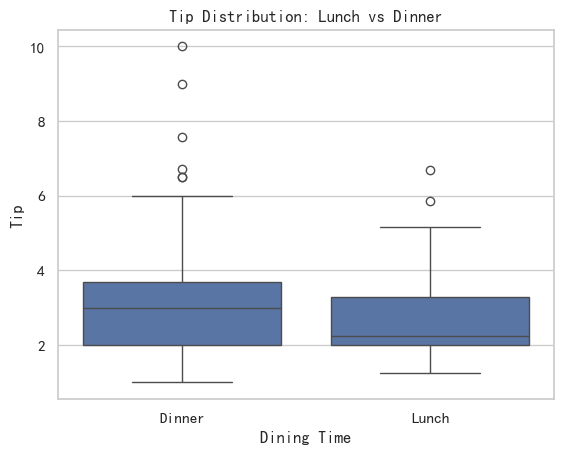

In [45]:
sns.boxplot(data=df_clean, x='time', y='tip')
plt.title('Tip Distribution: Lunch vs Dinner')
plt.xlabel('Dining Time')
plt.ylabel('Tip')
plt.show()

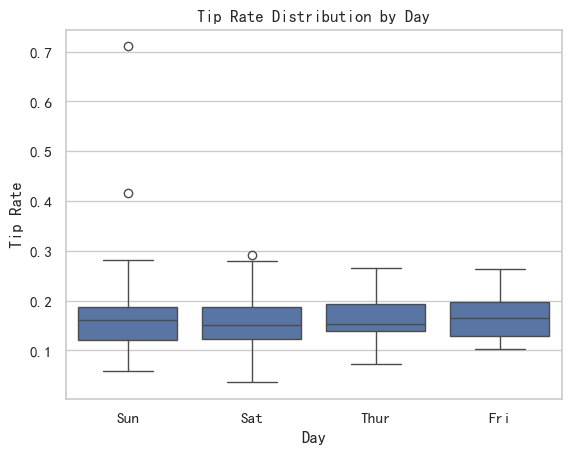

In [47]:
sns.boxplot(data=df_clean, x='day', y='tip_rate')
plt.title('Tip Rate Distribution by Day')
plt.xlabel('Day')
plt.ylabel('Tip Rate')
plt.show()

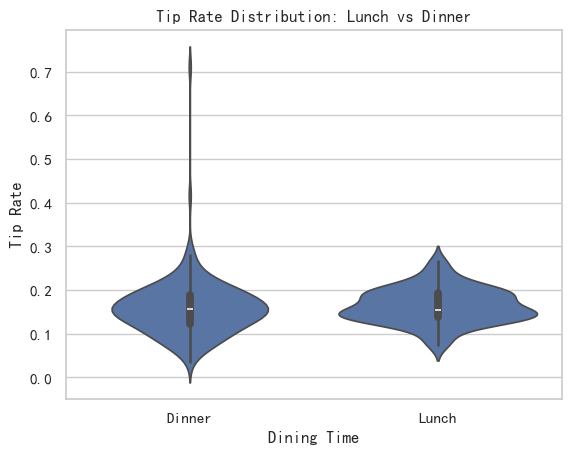

In [49]:
sns.violinplot(data=df_clean, x='time', y='tip_rate')
plt.title("Tip Rate Distribution: Lunch vs Dinner")
plt.xlabel("Dining Time")
plt.ylabel("Tip Rate")
plt.show()

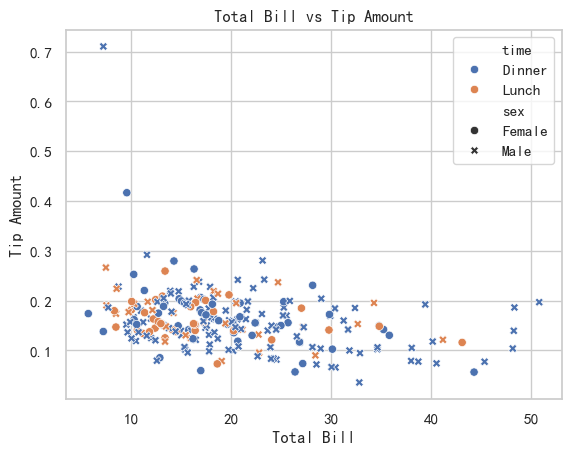

In [50]:
sns.scatterplot(data=df_clean, x='total_bill', y='tip_rate', hue='time', style='sex')
plt.title("Total Bill vs Tip Amount")
plt.xlabel("Total Bill")
plt.ylabel("Tip Amount")
plt.show()

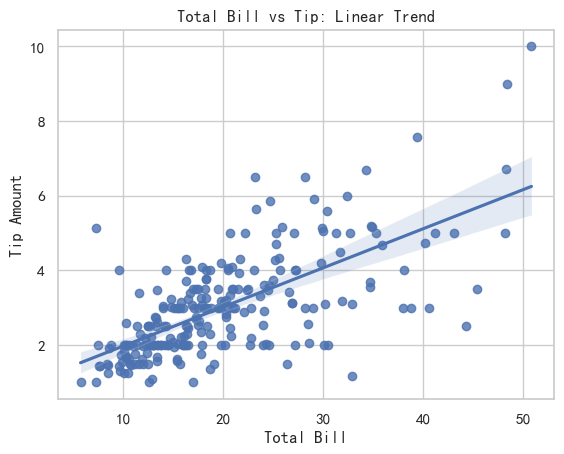

In [51]:
sns.regplot(data=df_clean, x='total_bill', y='tip')
plt.title("Total Bill vs Tip: Linear Trend")
plt.xlabel("Total Bill")
plt.ylabel("Tip Amount")
plt.show()

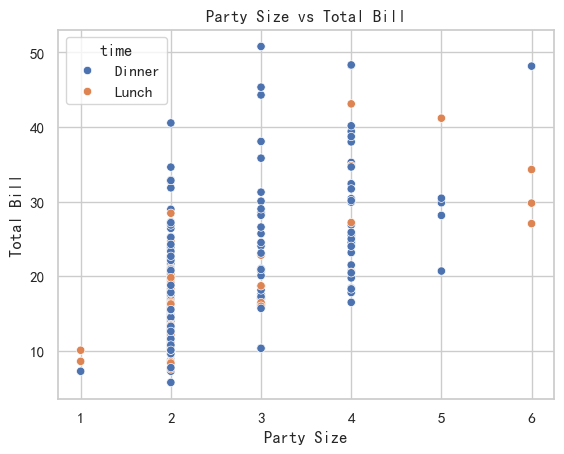

In [52]:
sns.scatterplot(data=df_clean, x='size', y='total_bill', hue='time')
plt.title("Party Size vs Total Bill")
plt.xlabel("Party Size")
plt.ylabel("Total Bill")
plt.show()

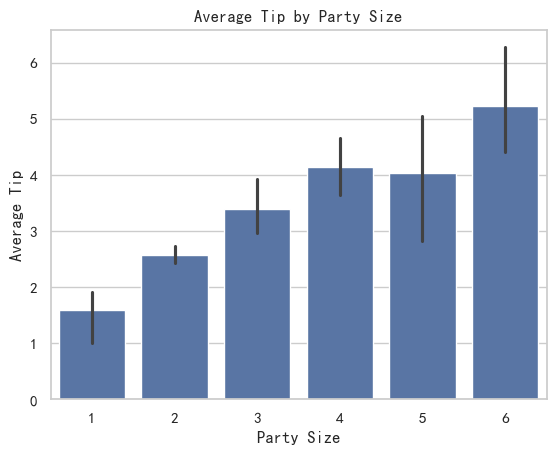

In [59]:
sns.barplot(data=df_clean, x='size', y='tip')
plt.title("Average Tip by Party Size")
plt.xlabel("Party Size")
plt.ylabel("Average Tip")
plt.show()

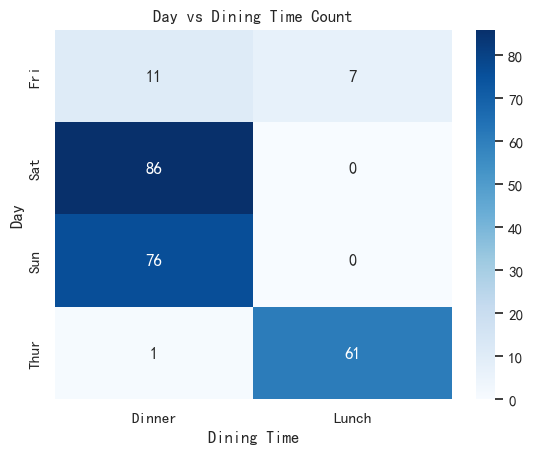

In [65]:
cross_day_time = pd.crosstab(df_clean['day'], df_clean['time'])
sns.heatmap(cross_day_time, annot=True, fmt='d', cmap='Blues')
plt.title("Day vs Dining Time Count")
plt.xlabel("Dining Time")
plt.ylabel("Day")
plt.show()

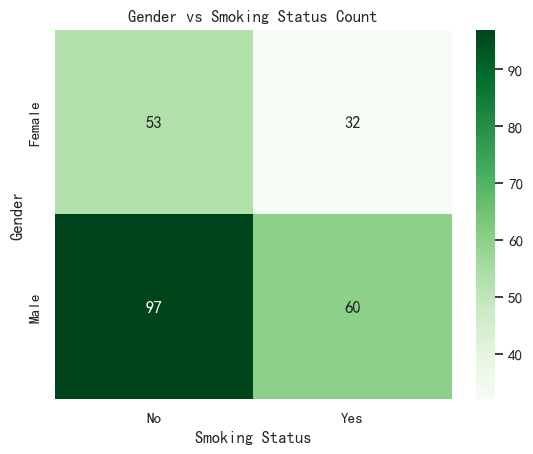

In [66]:
cross_sex_smoker = pd.crosstab(df_clean['sex'], df_clean['smoker'])
sns.heatmap(cross_sex_smoker, annot=True, fmt='d', cmap='Greens')
plt.title("Gender vs Smoking Status Count")
plt.xlabel("Smoking Status")
plt.ylabel("Gender")
plt.show()

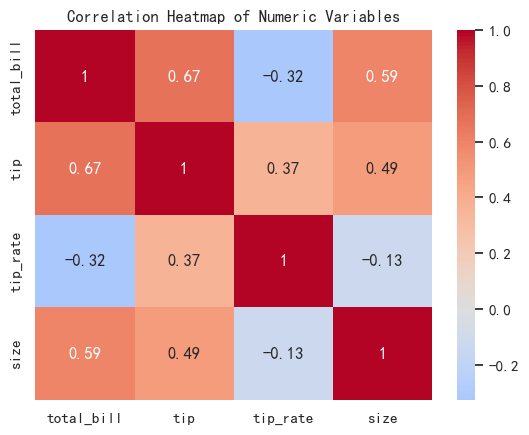

In [67]:
numeric_cols = ['total_bill', 'tip', 'tip_rate', 'size']
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

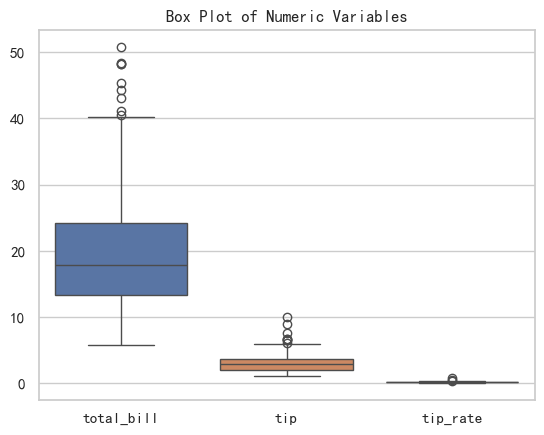

In [75]:
sns.boxplot(data=df_clean[['total_bill', 'tip', 'tip_rate']])
plt.title("Box Plot of Numeric Variables")
plt.show()